In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import parse_slurm as ps
import data_analysis as da
import glob
import pandas as pd

In [3]:
metric = 'AveRSS'

# Docking Protein-Protein Memory Analysis 

In [4]:
dpp = pd.read_csv('../data/data_dpp.csv')
dpp = ps.remove_outliers(dpp, threshold=1, column=metric)
dpp_mem = dpp[['AveRSS', 'NCPUS']]

## Descriptive Analysis

In [5]:
for x in [4, 8, 16, 32]:
    group = dpp_mem[dpp_mem['NCPUS'] == int(x)]
    print(group.describe())
    cv = group.std() / group.mean()
    print('cv', '   ', round(cv[metric], 6))

          AveRSS  NCPUS
count  13.000000   13.0
mean    0.688463    4.0
std     0.012373    0.0
min     0.673008    4.0
25%     0.675336    4.0
50%     0.691588    4.0
75%     0.693476    4.0
max     0.709528    4.0
cv     0.017972
          AveRSS  NCPUS
count  16.000000   16.0
mean    1.194457    8.0
std     0.009454    0.0
min     1.181544    8.0
25%     1.188050    8.0
50%     1.193000    8.0
75%     1.201929    8.0
max     1.212244    8.0
cv     0.007915
          AveRSS  NCPUS
count  10.000000   10.0
mean    2.219257   16.0
std     0.006195    0.0
min     2.207268   16.0
25%     2.215786   16.0
50%     2.220070   16.0
75%     2.222774   16.0
max     2.228660   16.0
cv     0.002792
          AveRSS  NCPUS
count  13.000000   13.0
mean    3.919600   32.0
std     0.053626    0.0
min     3.877588   32.0
25%     3.890256   32.0
50%     3.915472   32.0
75%     3.916520   32.0
max     4.085656   32.0
cv     0.013681


## Boxplots

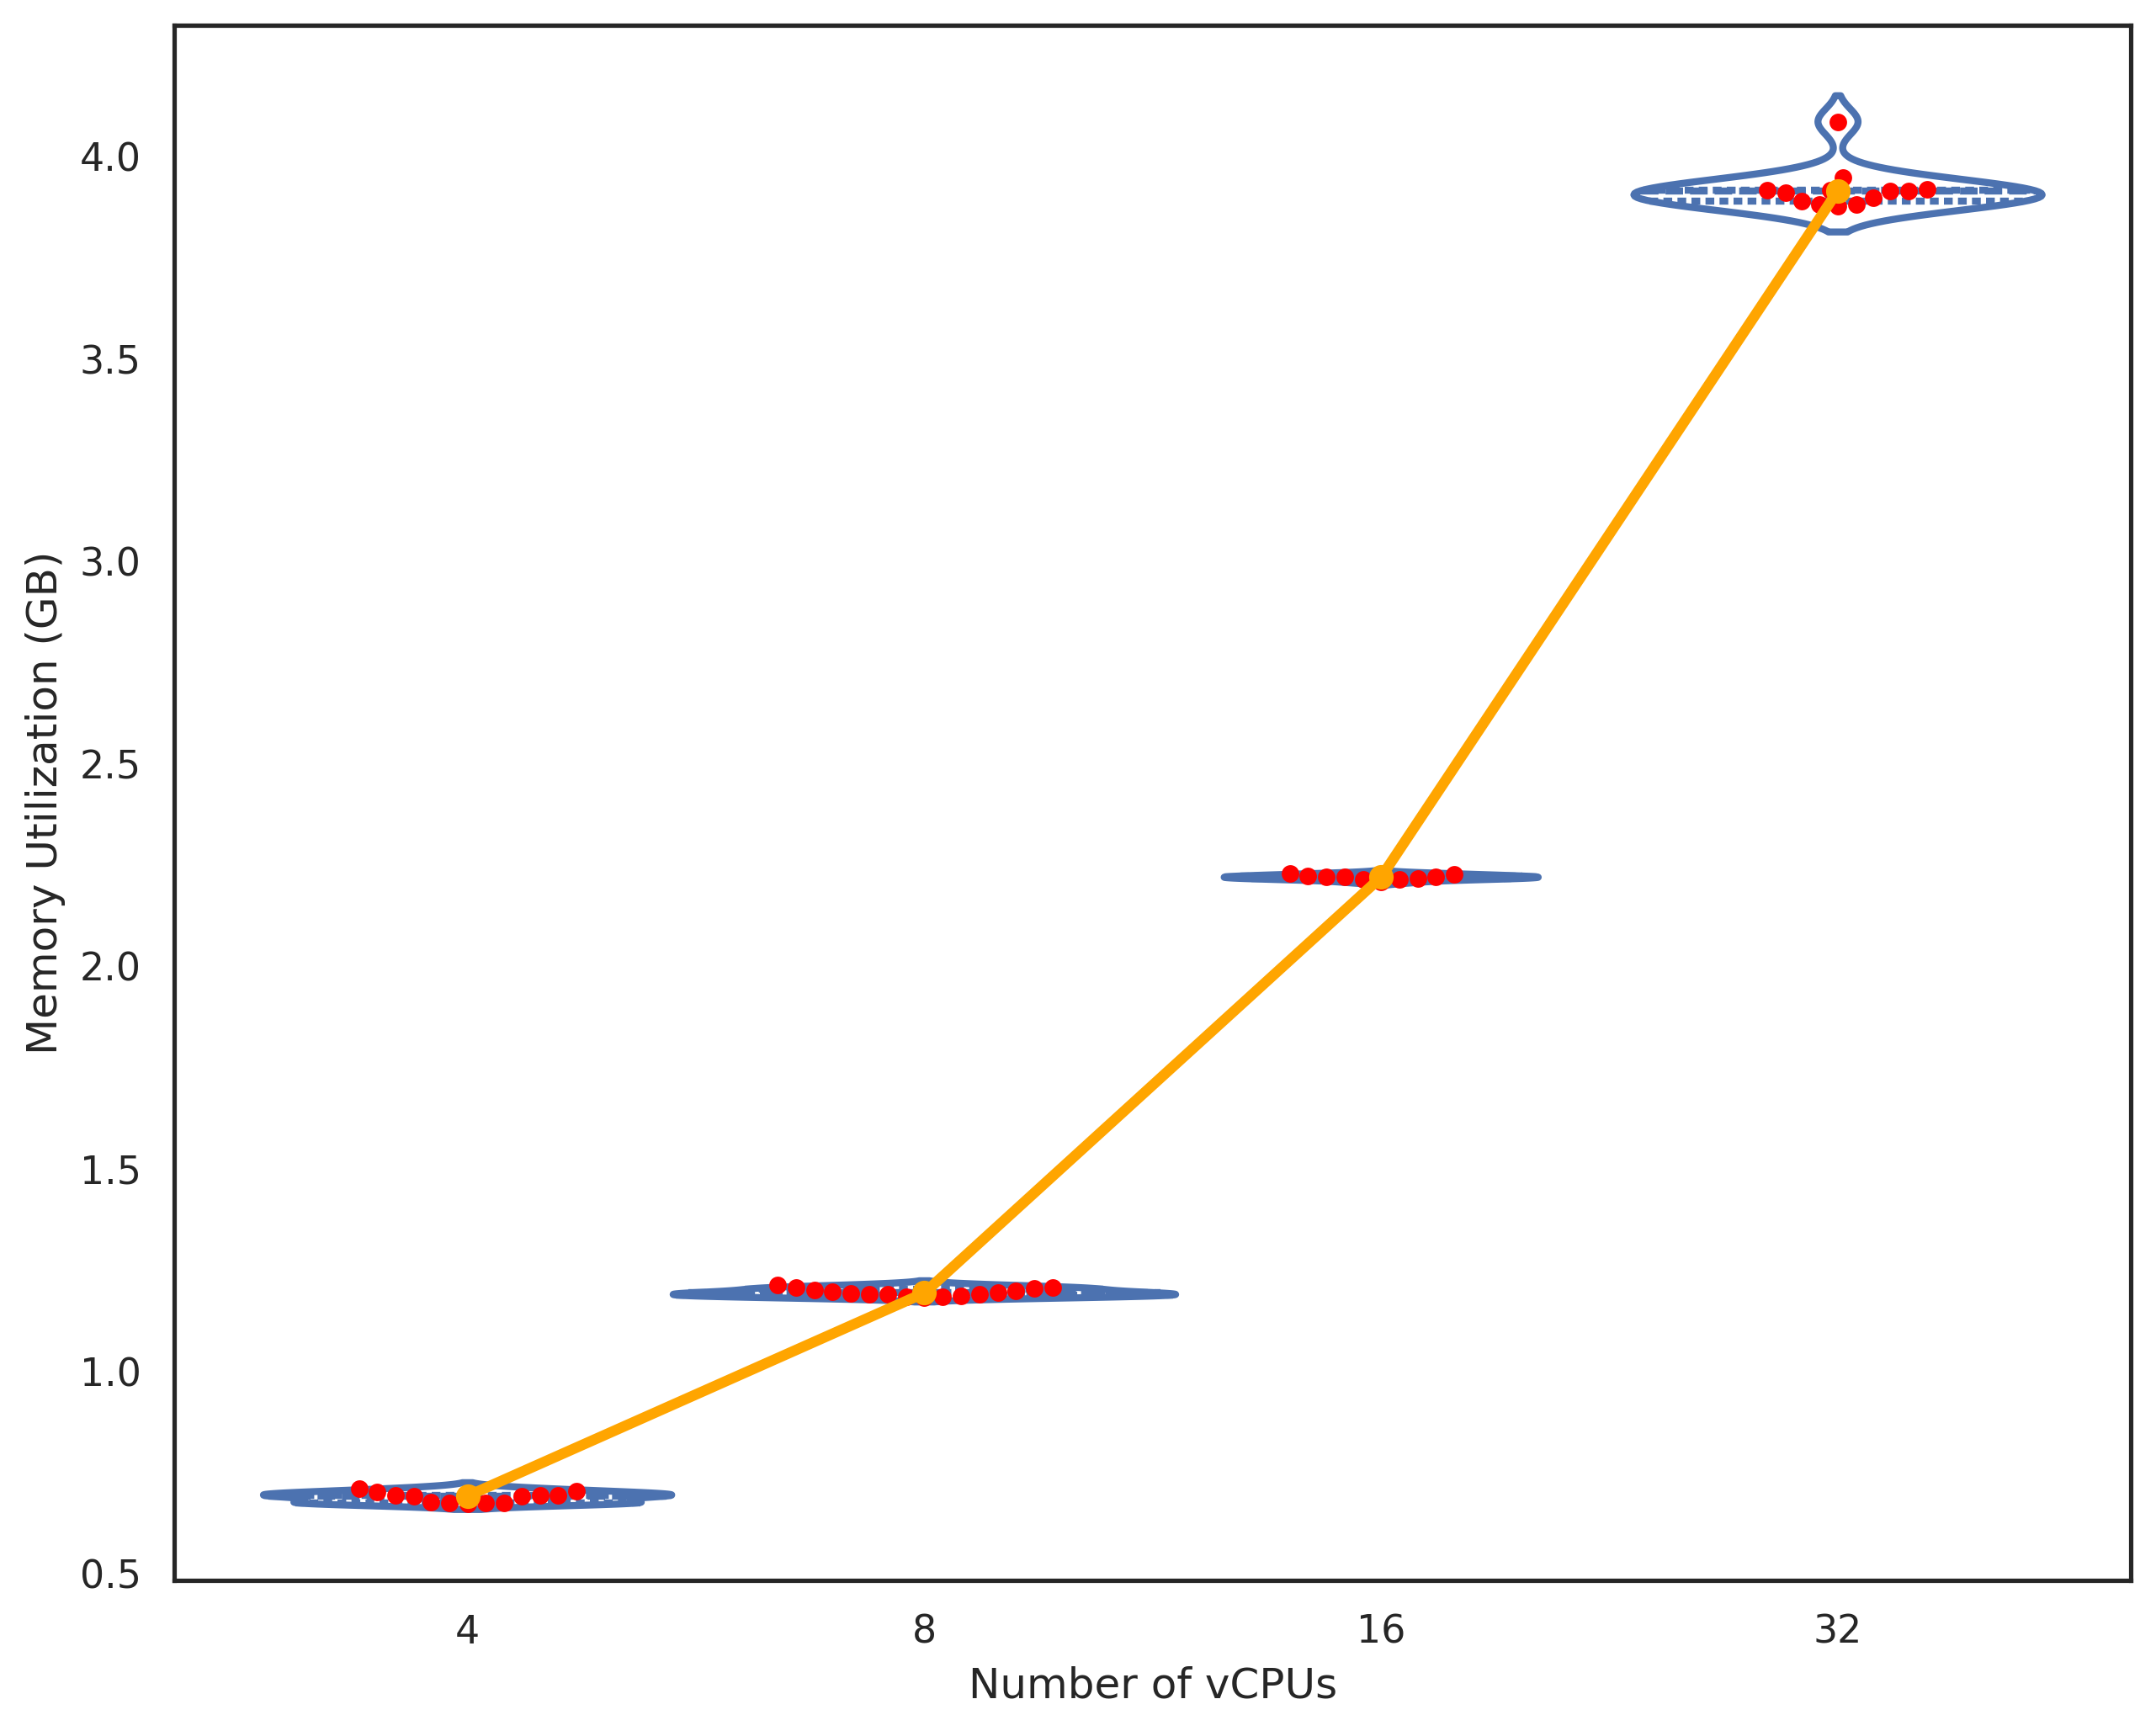

In [6]:
da.show_boxplot(
    dpp_mem, "Average Memory (Resident Set Size) of DPP Workflow at Varying Parallelism Degrees", metric=metric,
    x_label="Number of vCPUs", y_label="Memory Utilization (GB)", store=True
)

### Normality Test: Shapiro-Wilk and QQ-Plots

In [7]:
normality = ps.test_normality(dpp_mem, column=metric)
print(normality)

   NCPUS      STAT    PVALUE
0      4  0.883998  0.080797
1      8  0.945258  0.418464
2     16  0.977862  0.952709
3     32  0.646873  0.000171


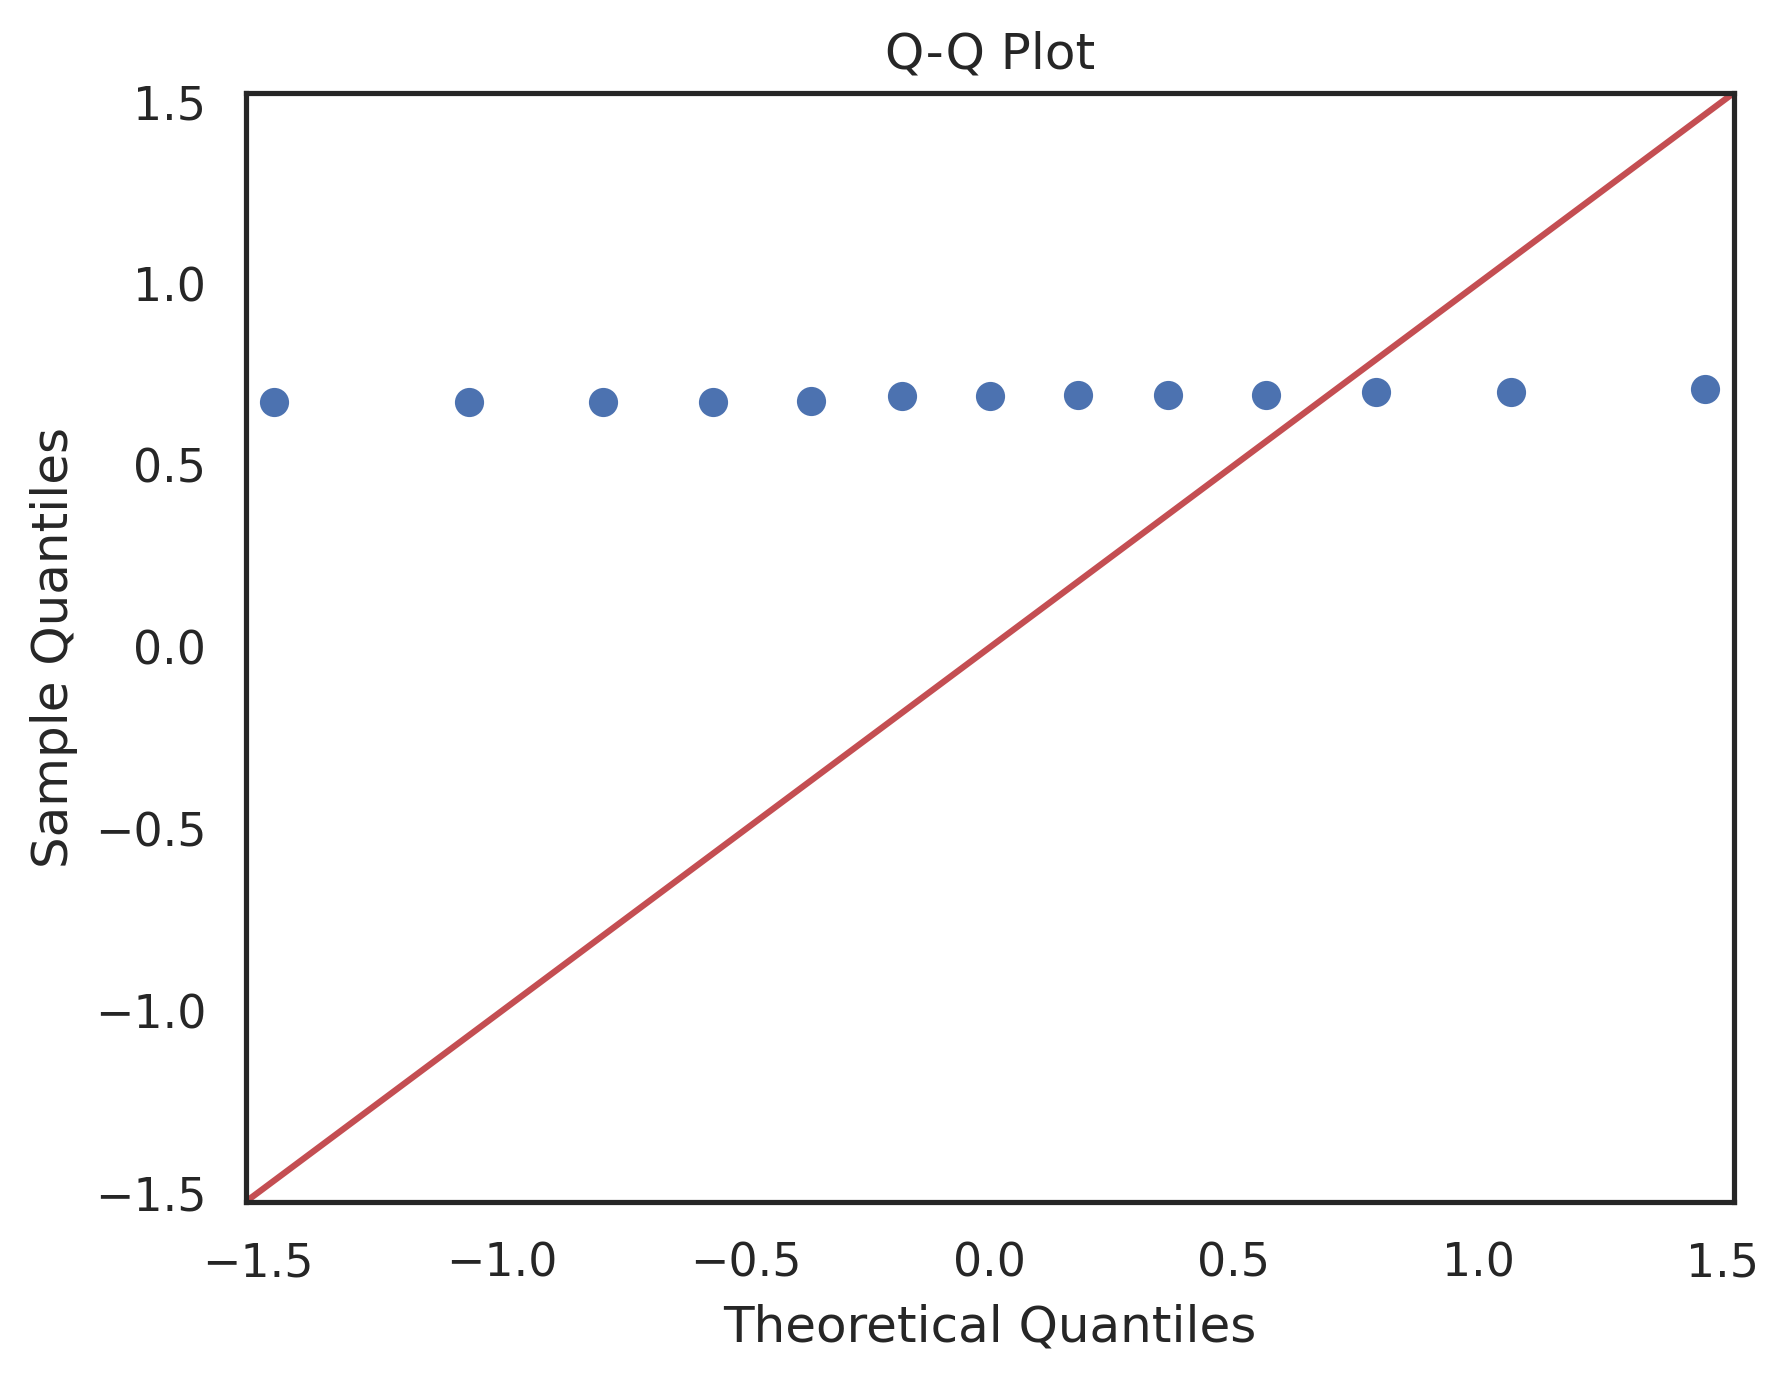

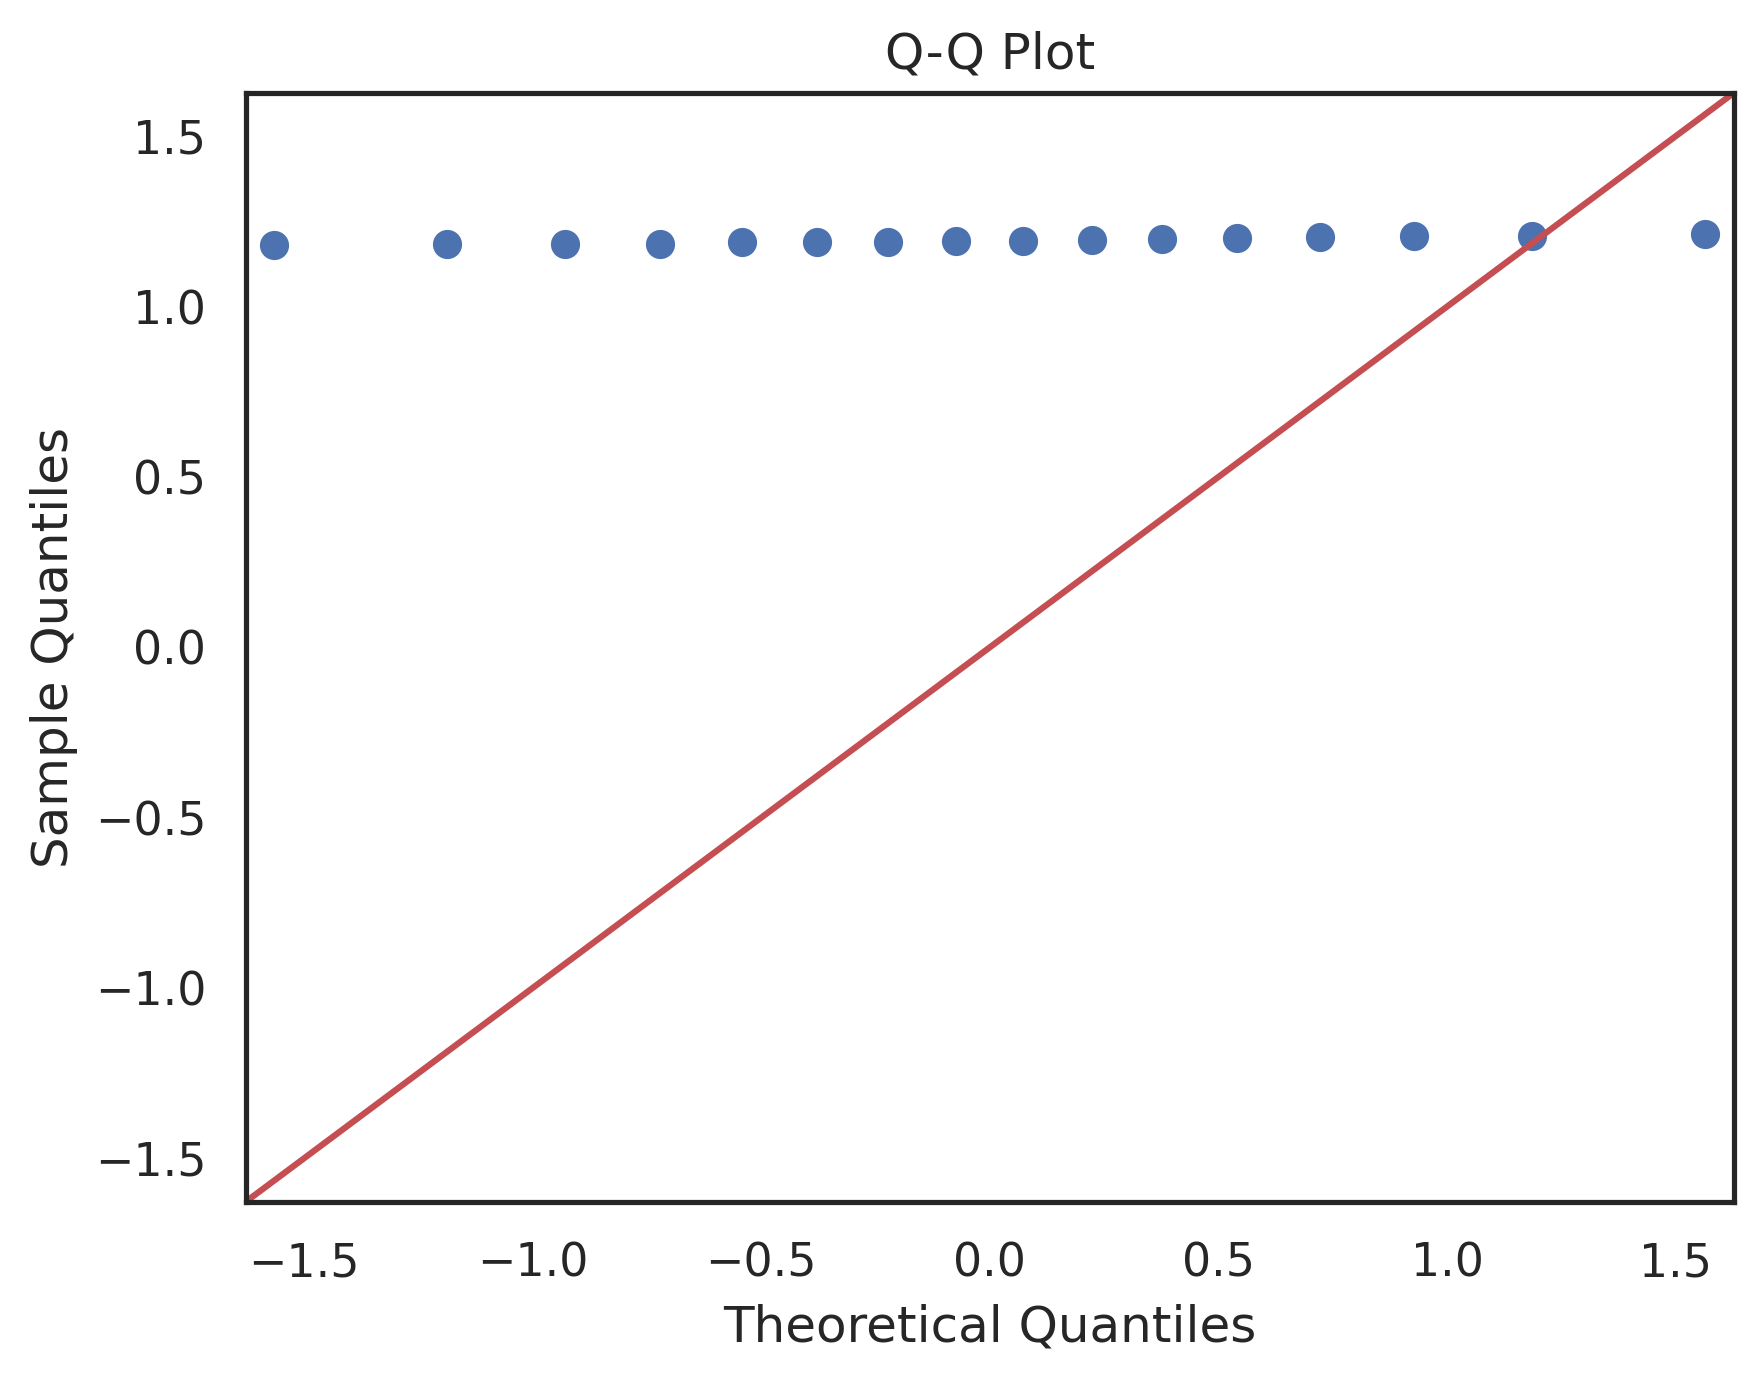

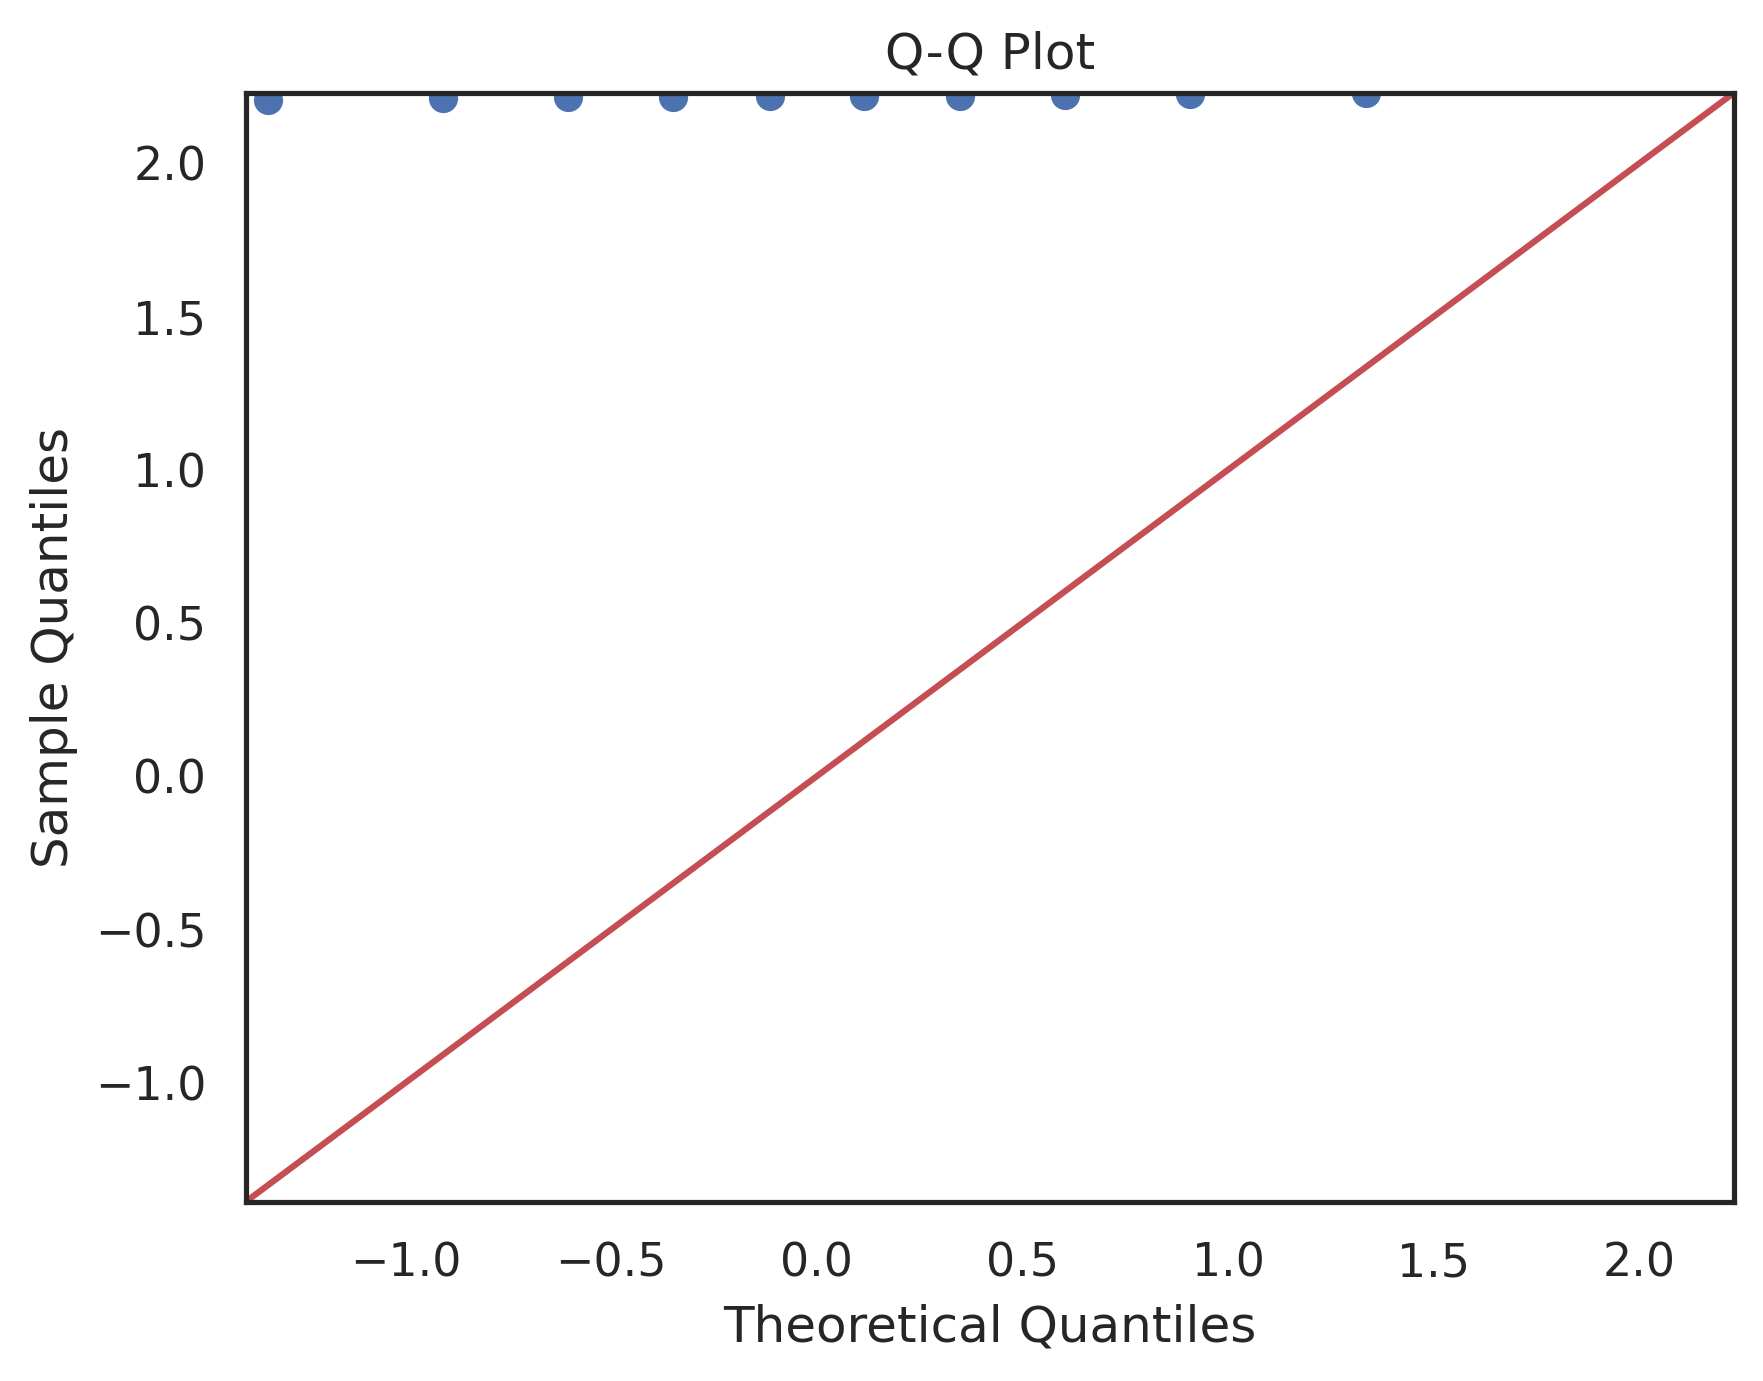

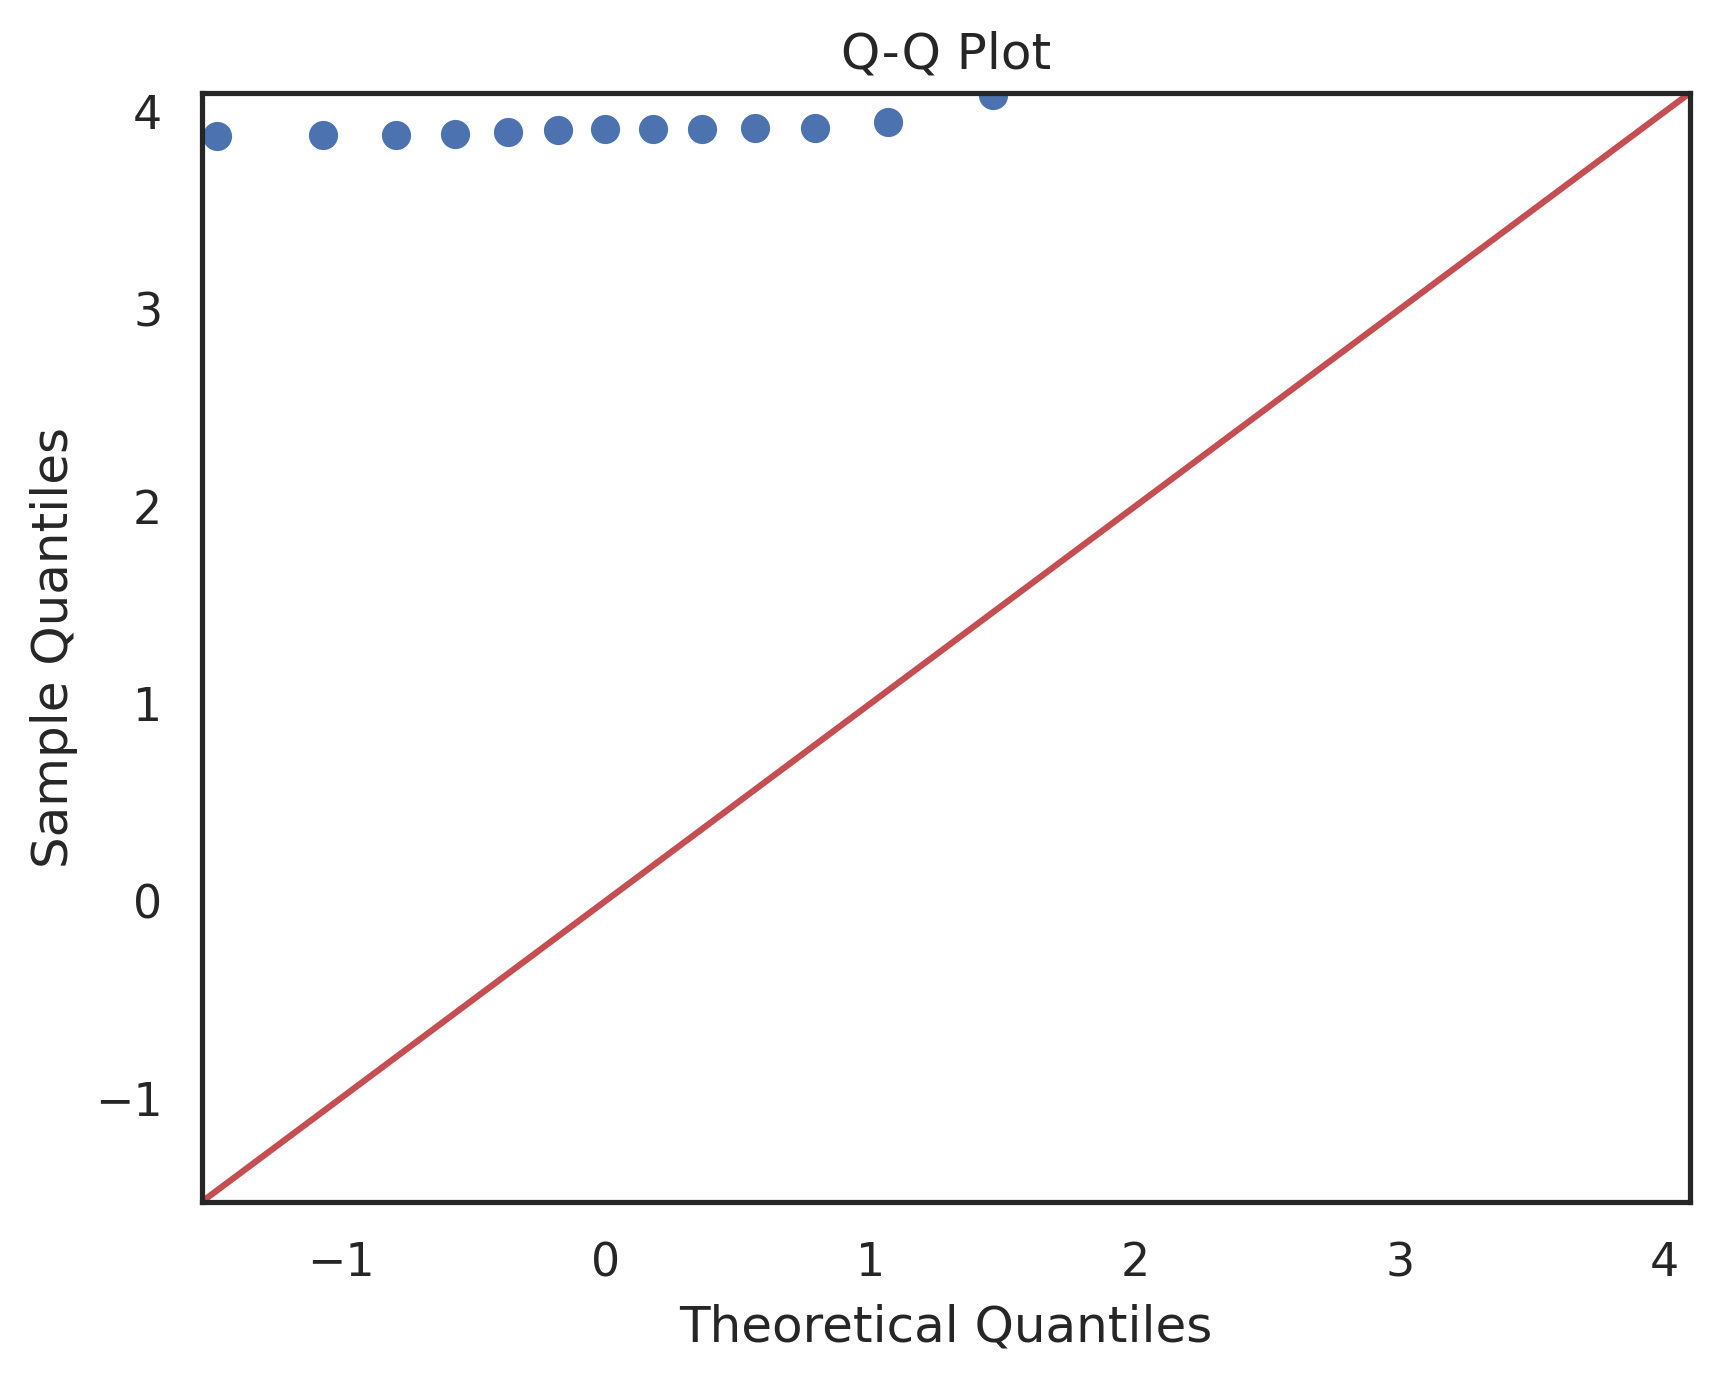

In [8]:
ps.generate_qq(dpp_mem, column=metric)

## Hypothesis Testing: Kruskal-Wallis

In [9]:
ps.test_hypothesis_kruskal(dpp_mem, column=metric)

(47.575471698113205, 2.621838394439671e-10)

## Effect Size: Cliff's Delta

In [10]:
ps.calc_cliffs_delta(dpp_mem, column=metric)

,CPUS-GROUPS,Value,Result
0,"(4, 8)",-1.0,large
1,"(8, 16)",-1.0,large
2,"(16, 32)",-1.0,large


## Effect Size: Percentage Improvement

In [11]:
ps.calc_groups_improvement(dpp_mem, column=metric)

,CPU-GROUPS,Median Improvement,Median Delta,Mean Improvement,Mean Delta
0,"(4, 8)",-42.029505,-0.501412,-42.361835,-0.505994
1,"(8, 16)",-46.262956,-1.027070,-46.177599,-1.024800
2,"(16, 32)",-43.300067,-1.695402,-43.380518,-1.700343
3,"(4, 32)",-82.337046,-3.223884,-82.435366,-3.231137


# Docking Antibody-Antigen Memory Analysis 

In [12]:
daa = pd.read_csv('../data/data_daa.csv')
daa = ps.remove_outliers(daa, threshold=1, column=metric)
daa_mem = daa[['AveRSS', 'NCPUS']]

# Descriptive Analysis

In [13]:
for x in [4, 8, 16, 32]:
    group = daa_mem[daa_mem['NCPUS'] == int(x)]
    print(group.describe())

          AveRSS  NCPUS
count  11.000000   11.0
mean    1.468575    4.0
std     0.011205    0.0
min     1.456736    4.0
25%     1.459400    4.0
50%     1.466160    4.0
75%     1.476794    4.0
max     1.487932    4.0
          AveRSS  NCPUS
count  13.000000   13.0
mean    2.616568    8.0
std     0.011559    0.0
min     2.595208    8.0
25%     2.615932    8.0
50%     2.622616    8.0
75%     2.623360    8.0
max     2.628628    8.0
          AveRSS  NCPUS
count  10.000000   10.0
mean    4.903372   16.0
std     0.016867    0.0
min     4.879384   16.0
25%     4.892020   16.0
50%     4.904292   16.0
75%     4.911416   16.0
max     4.929936   16.0
          AveRSS  NCPUS
count  11.000000   11.0
mean    9.472577   32.0
std     0.041204    0.0
min     9.359000   32.0
25%     9.467076   32.0
50%     9.480864   32.0
75%     9.488274   32.0
max     9.514128   32.0


## Boxplots

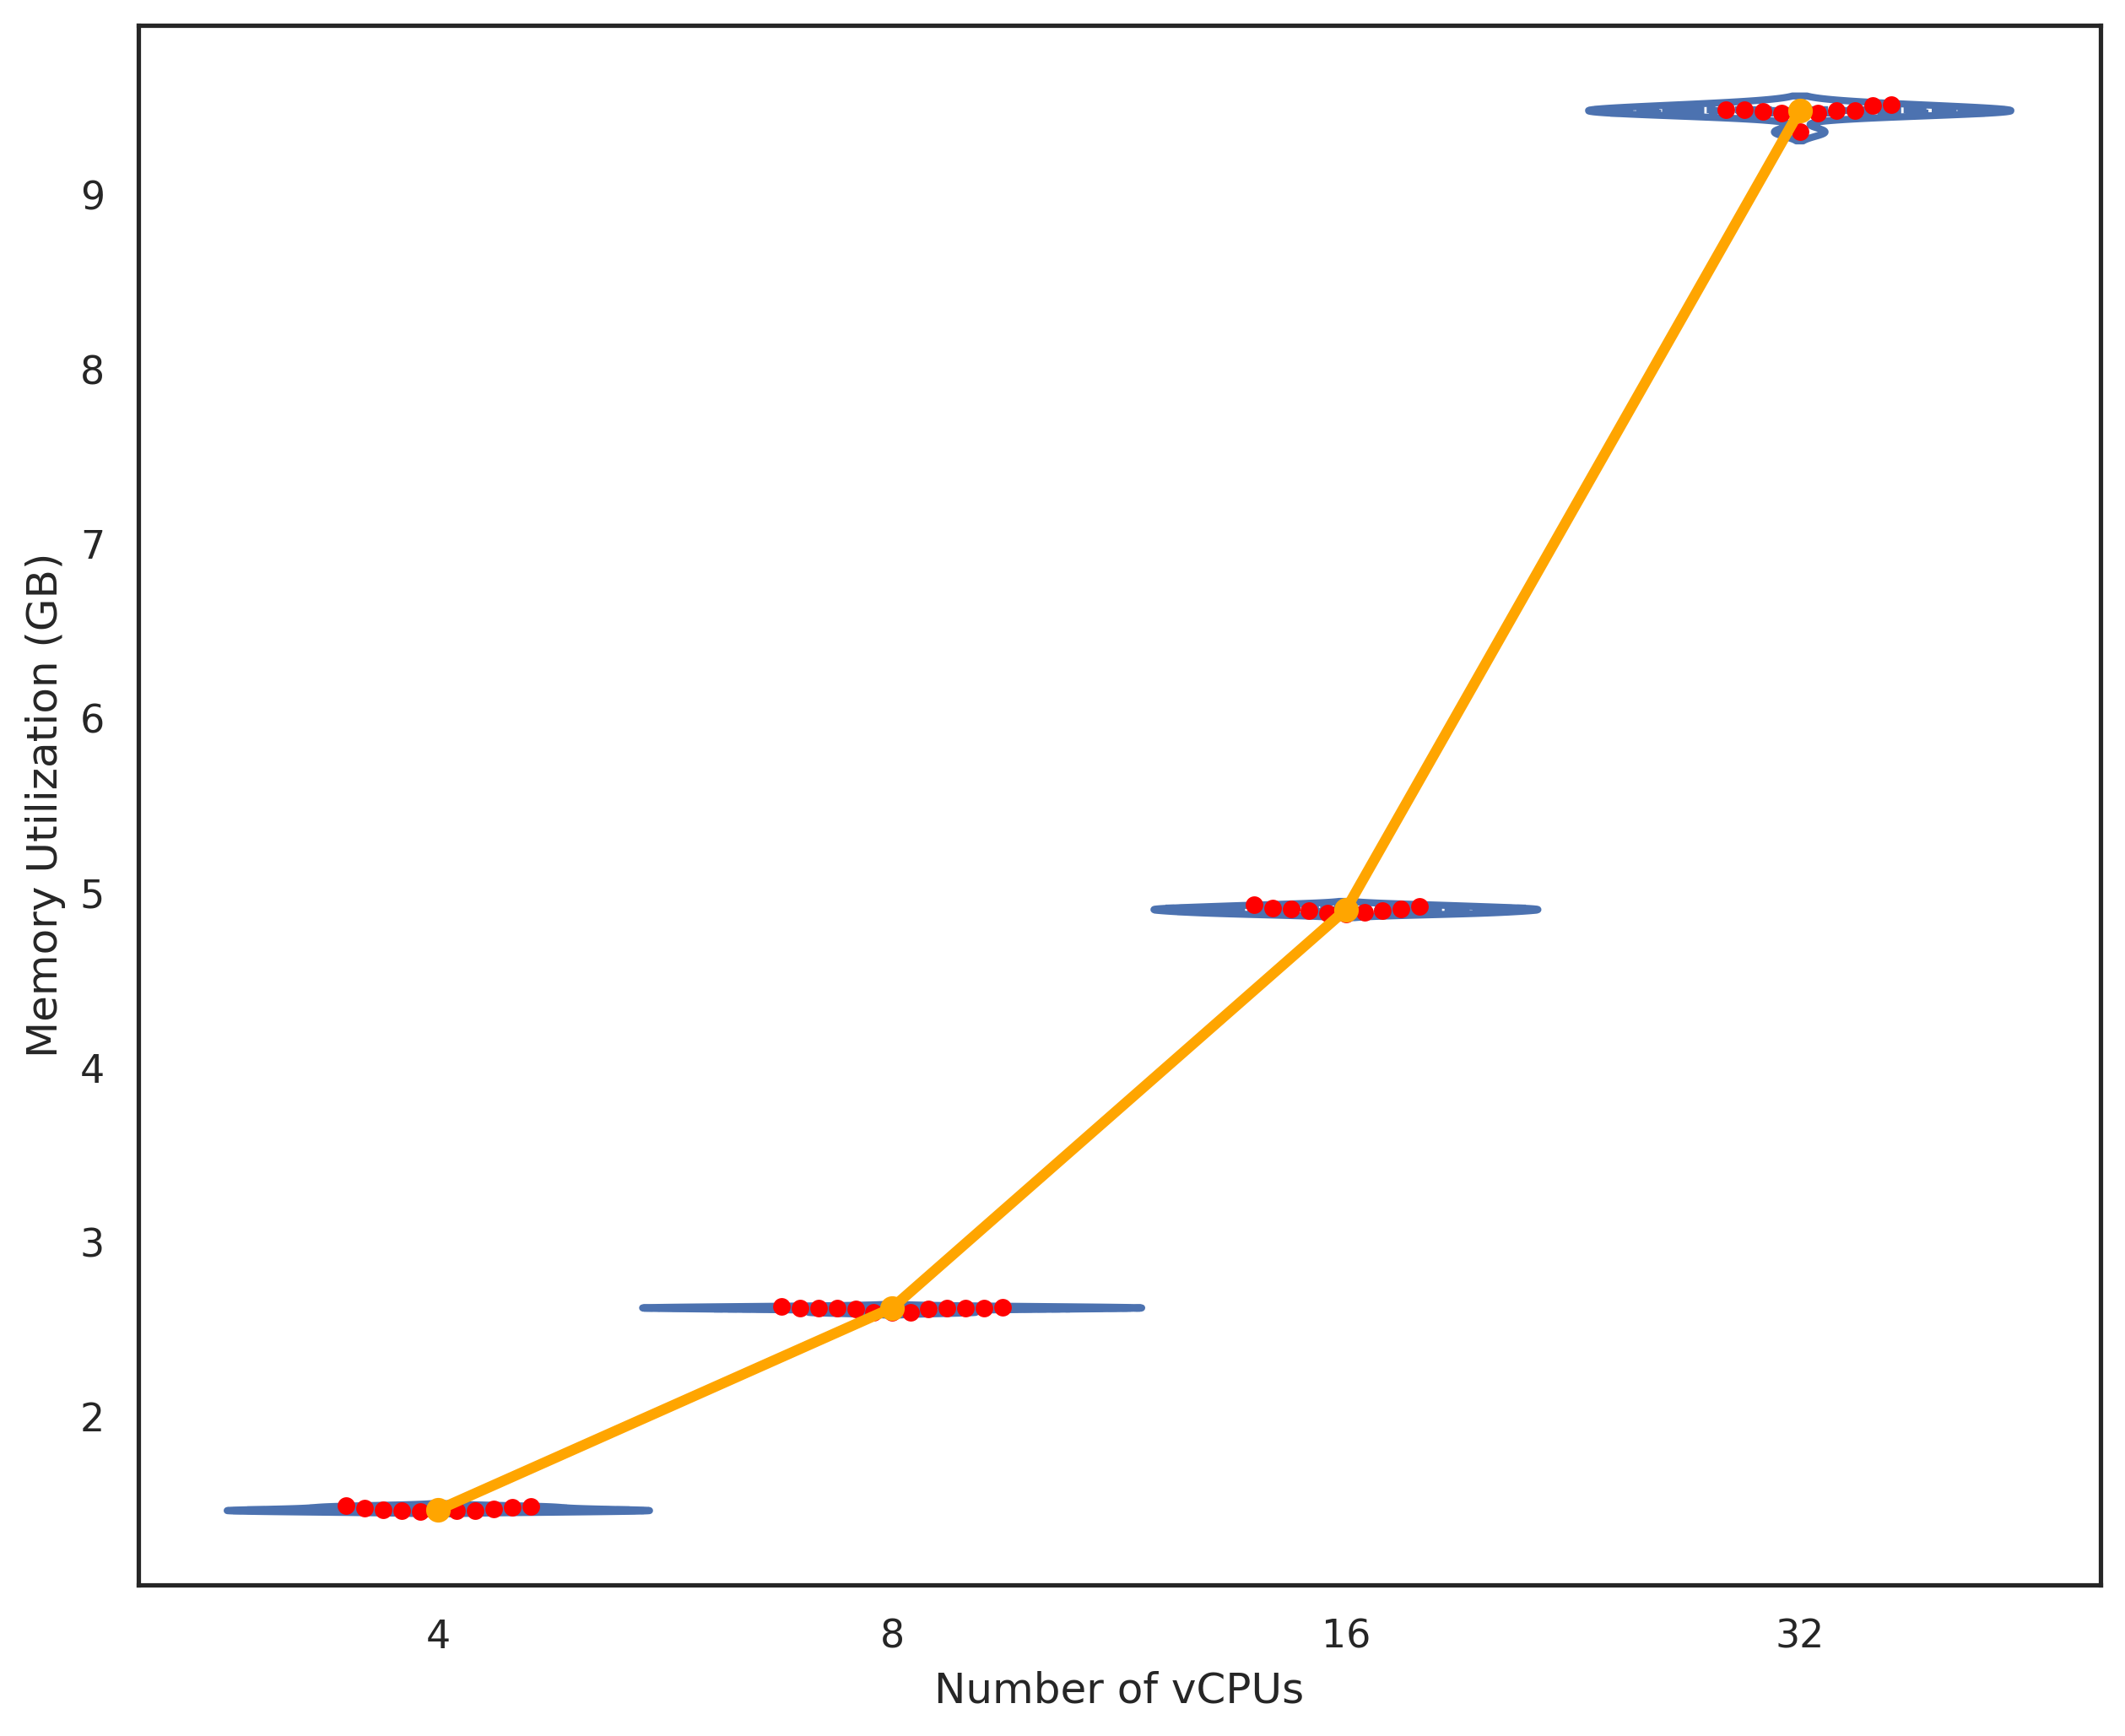

In [14]:
da.show_boxplot(
    daa_mem, "Average Memory (Resident Set Size) of DAA Workflow at Varying Parallelism Degrees", metric=metric,
    x_label="Number of vCPUs", y_label="Memory Utilization (GB)", store=True
)

## Normality Test: Shapiro-Wilk and QQ-Plots

In [15]:
normality = ps.test_normality(daa_mem, column=metric)
print(normality)

   NCPUS      STAT    PVALUE
0      4  0.896728  0.168538
1      8  0.782967  0.004308
2     16  0.960035  0.786268
3     32  0.725114  0.000987


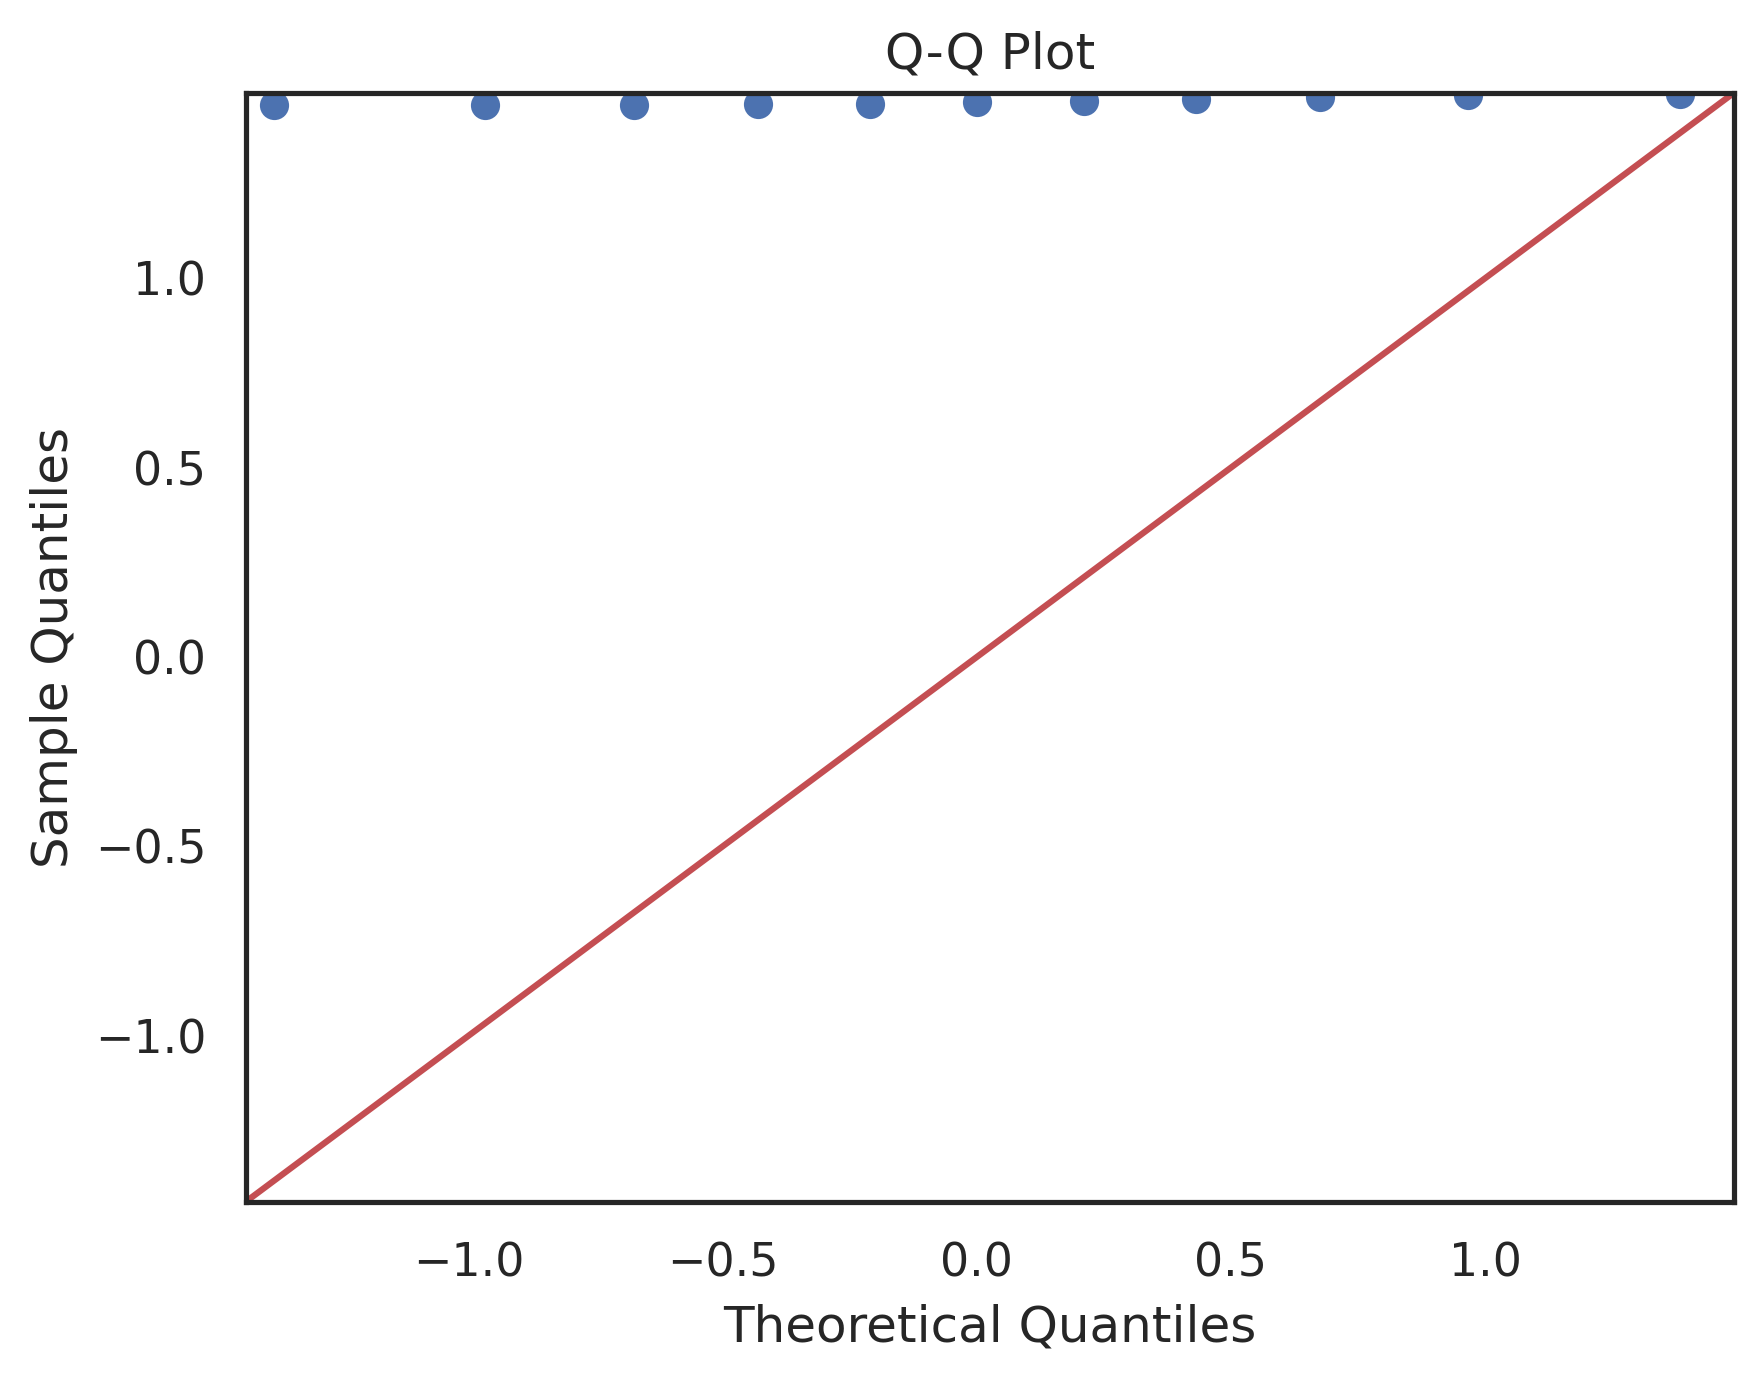

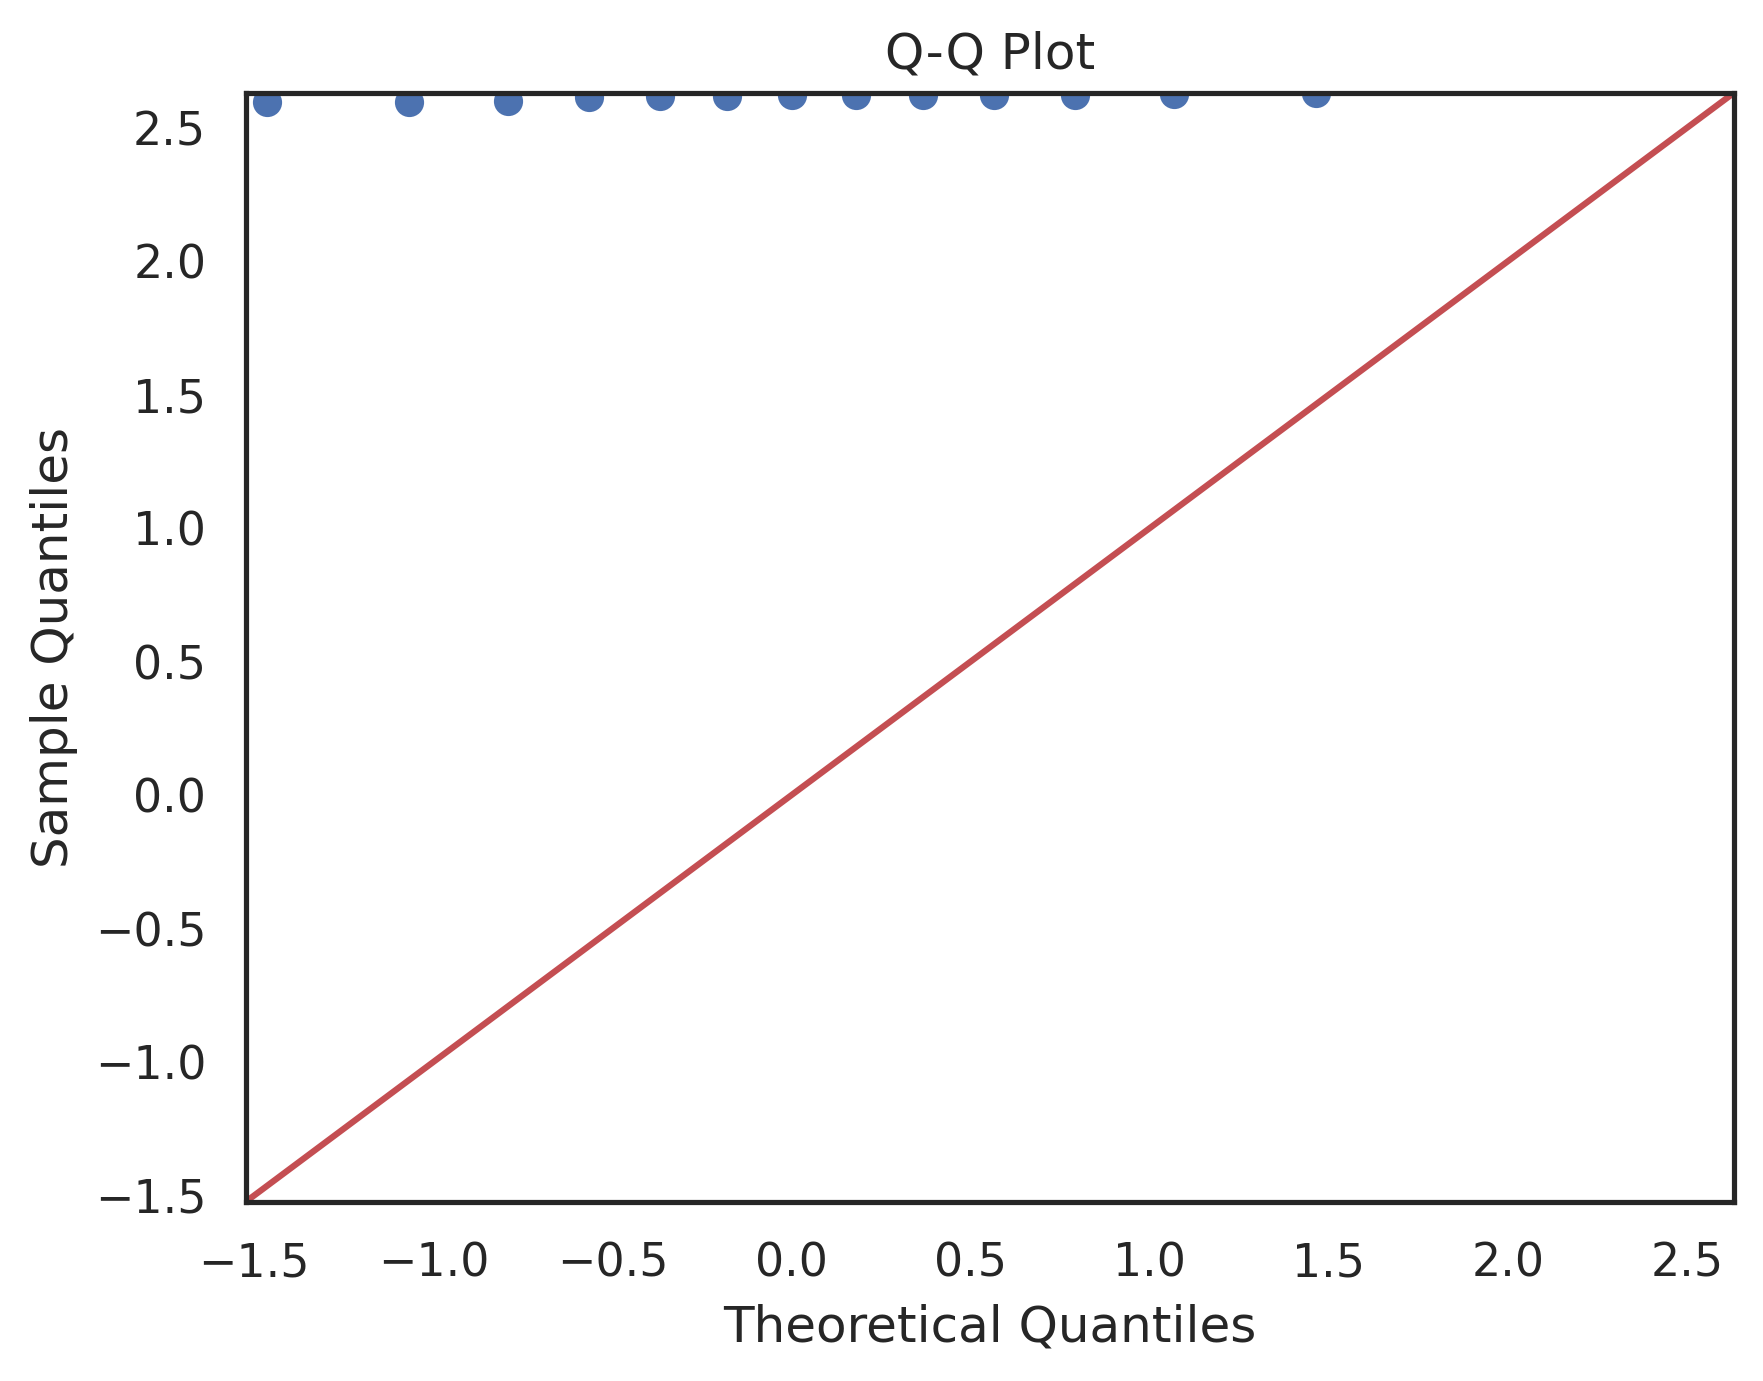

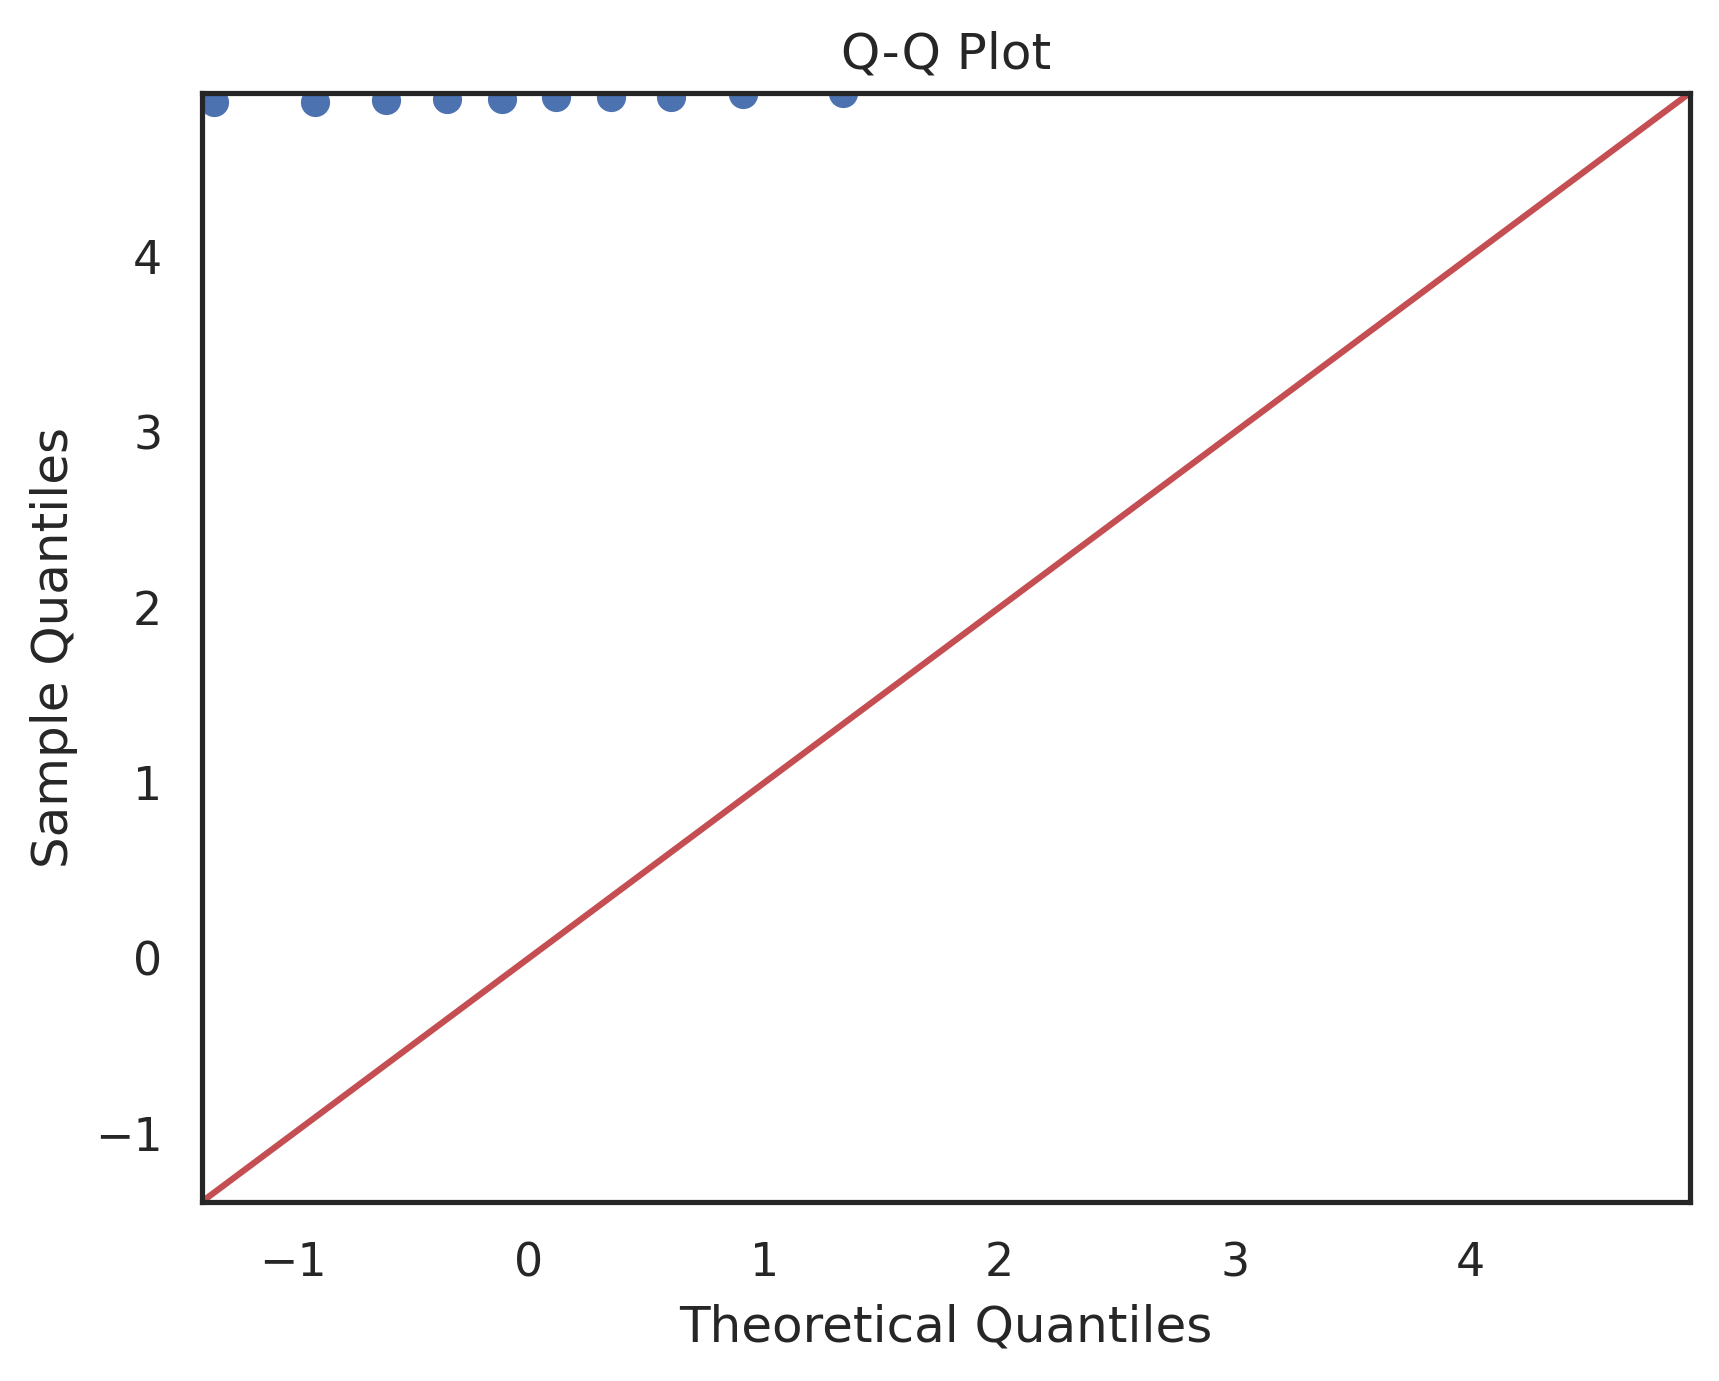

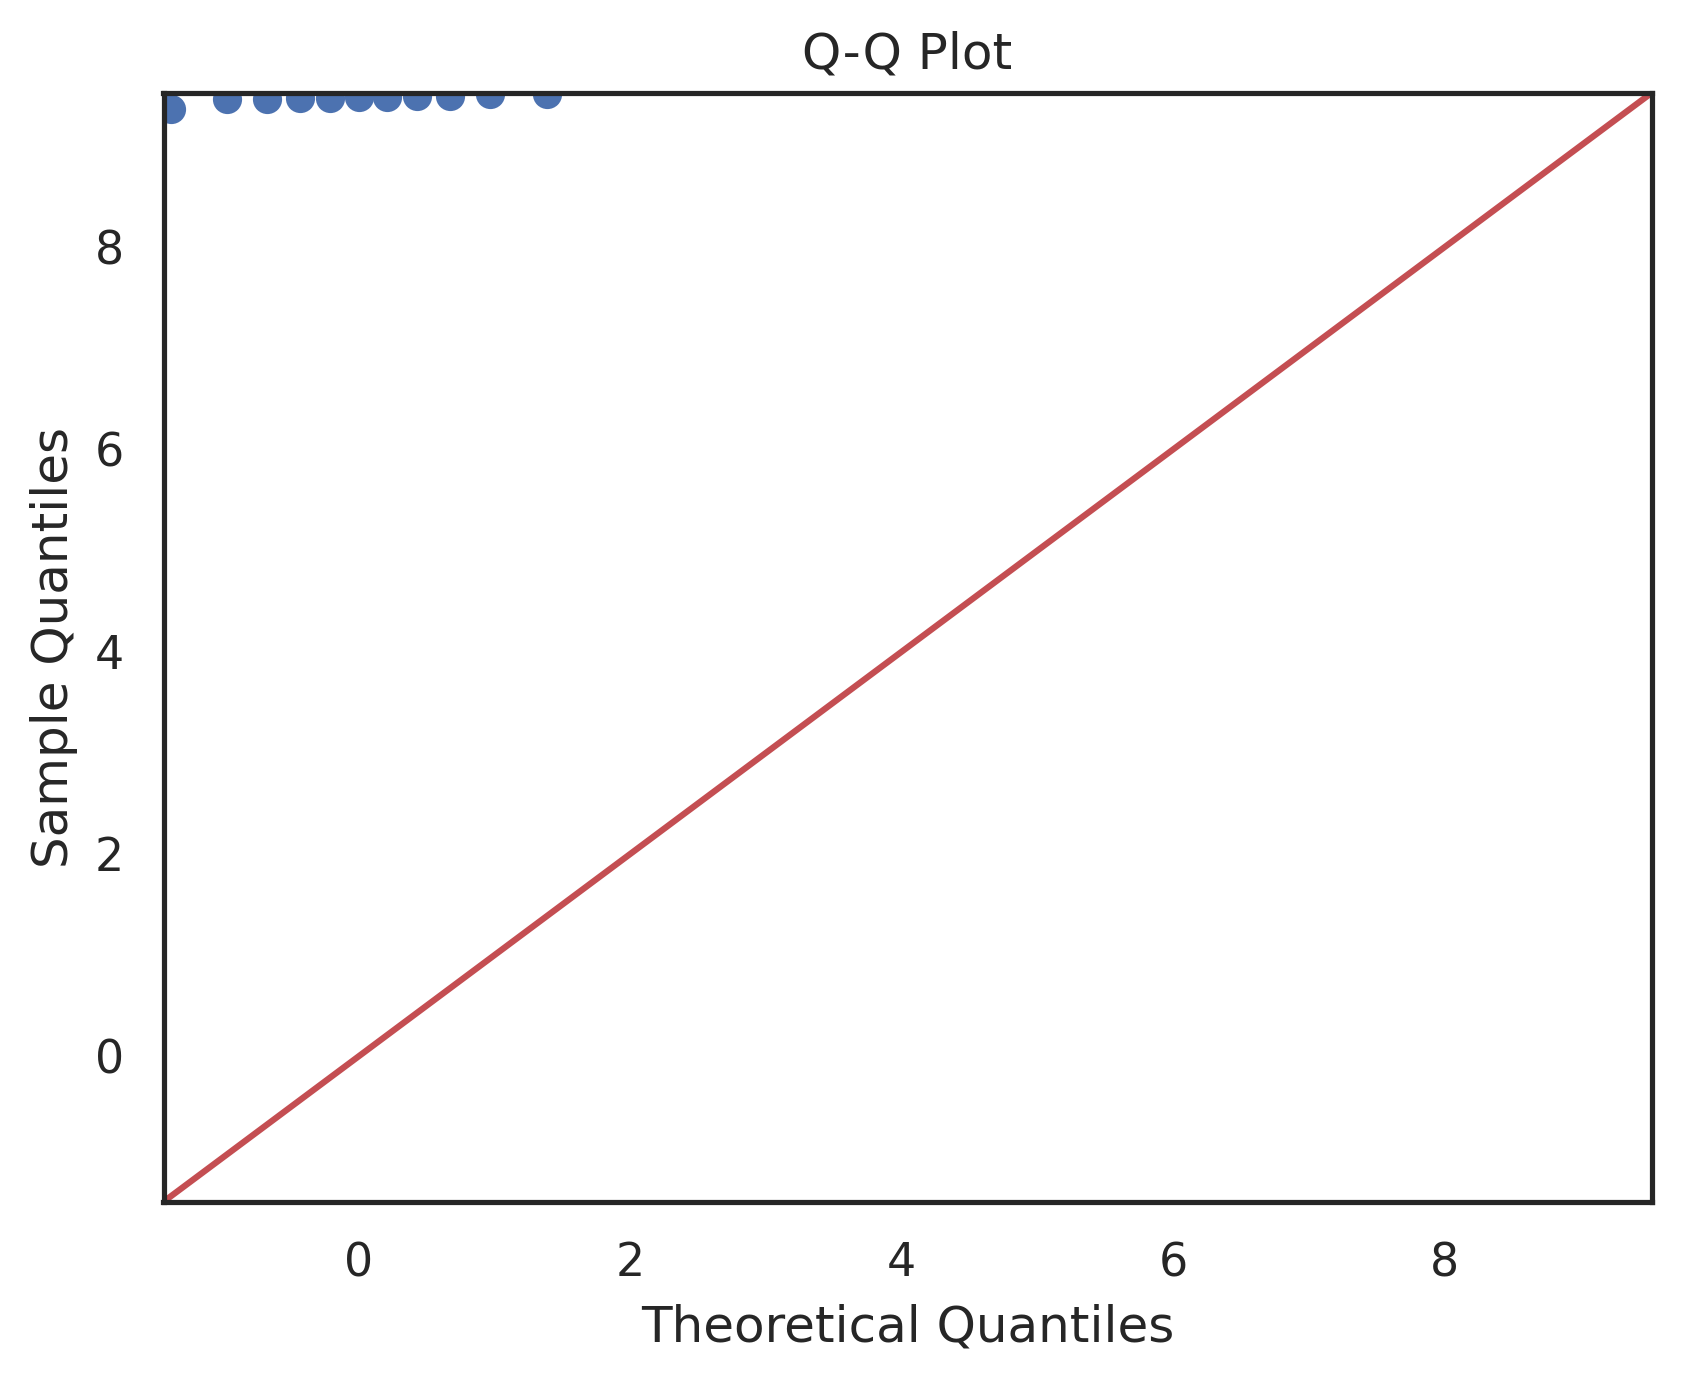

In [16]:
ps.generate_qq(daa_mem, column=metric)

## Hypothesis Testing: Kruskal-Wallis

In [17]:
ps.test_hypothesis_kruskal(daa_mem, column=metric)

(41.191304347826076, 5.955915053319807e-09)

## Effect Size: Cliff's Delta

In [18]:
ps.calc_cliffs_delta(daa_mem, column=metric)

,CPUS-GROUPS,Value,Result
0,"(4, 8)",-1.0,large
1,"(8, 16)",-1.0,large
2,"(16, 32)",-1.0,large


## Effect Size: Percentage Improvement

In [19]:
ps.calc_groups_improvement(daa_mem, column=metric)

,CPU-GROUPS,Median Improvement,Median Delta,Mean Improvement,Mean Delta
0,"(4, 8)",-44.095514,-1.156456,-43.873981,-1.147992
1,"(8, 16)",-46.524065,-2.281676,-46.637382,-2.286804
2,"(16, 32)",-48.271677,-4.576572,-48.236133,-4.569205
3,"(4, 32)",-84.535587,-8.014704,-84.496560,-8.004001
